# HW1 Code Template (Q3a + Q4b)

## Q3a – Logistic Regression (UCLA admissions binary.csv)
Dataset: admit, gre, gpa, rank.

This cell fetches the CSV from UCLA. If downloads fail, download `binary.csv` manually and load it from disk.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [3]:
url = "https://stats.idre.ucla.edu/stat/data/binary.csv"
df = pd.read_csv(url)

y = df["admit"].astype(int)
X = df[["gre", "gpa", "rank"]].copy()

categorical = ["rank"]
numeric = ["gre", "gpa"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical),
    ]
)

# Weak regularization to resemble statsmodels/R behavior
model = LogisticRegression(C=1e6, solver="lbfgs", max_iter=10000)

clf = Pipeline(steps=[("prep", preprocess), ("lr", model)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification report:\n", classification_report(y_test, pred))


Accuracy: 0.69
Confusion matrix:
 [[65  3]
 [28  4]]

Classification report:
               precision    recall  f1-score   support

           0       0.70      0.96      0.81        68
           1       0.57      0.12      0.21        32

    accuracy                           0.69       100
   macro avg       0.64      0.54      0.51       100
weighted avg       0.66      0.69      0.61       100



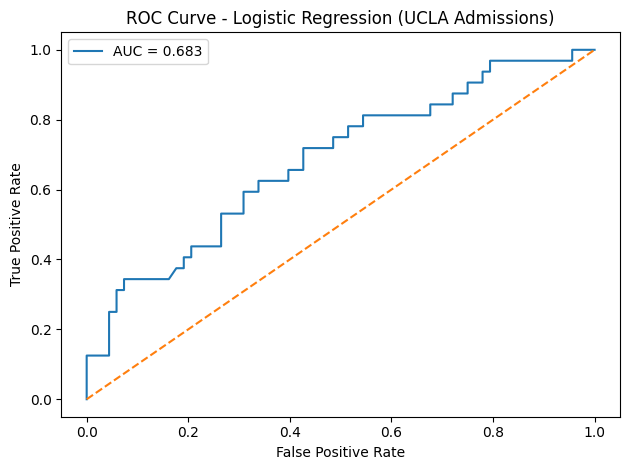

In [4]:
# ROC curve (screenshot this plot)
fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (UCLA Admissions)")
plt.legend()
plt.tight_layout()
plt.show()


## Q3b – XAI (weights-based explanation)

Print the learned coefficients. Pick one test example and explain which weights and feature values drove the prediction toward class 1 or 0.

In [5]:
prep = clf.named_steps["prep"]
lr = clf.named_steps["lr"]

ohe = prep.named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(["rank"]))
feature_names = numeric + cat_feature_names

coef = lr.coef_.ravel()
intercept = lr.intercept_[0]

coef_table = pd.DataFrame({"feature": feature_names, "weight": coef}).sort_values("weight", ascending=False)
print("Intercept:", intercept)
display(coef_table)


Intercept: -0.08744255233674901


,feature,weight
0,gre,0.301275
1,gpa,0.276566
2,rank_2,-0.493631
3,rank_3,-1.200949
4,rank_4,-1.435685


## Q4b – Scratch Logistic Regression on Iris (binary) + alternate squashing function

In [6]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def tanh_scaled(x):
    return 0.5 * (np.tanh(x) + 1)

class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.05, num_iterations=5000, activation="sigmoid"):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None
        self.activation = activation

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _activate(self, z):
        if self.activation == "sigmoid":
            return self._sigmoid(z)
        elif self.activation == "tanh_scaled":
            return tanh_scaled(z)
        else:
            raise ValueError("activation must be 'sigmoid' or 'tanh_scaled'")

    def fit(self, X, y):
        n, d = X.shape
        self.weights = np.zeros(d)
        self.bias = 0.0

        for _ in range(self.num_iterations):
            z = X @ self.weights + self.bias
            p = self._activate(z)

            dw = (1 / n) * (X.T @ (p - y))
            db = (1 / n) * np.sum(p - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        z = X @ self.weights + self.bias
        p = self._activate(z)
        return (p >= 0.5).astype(int)

iris = load_iris()
X = iris.data
y = (iris.target == 0).astype(int)  # setosa=1, others=0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

m_sig = LogisticRegressionScratch(activation="sigmoid")
m_sig.fit(X_train_s, y_train)
pred_sig = m_sig.predict(X_test_s)
acc_sig = (pred_sig == y_test).mean()

m_tanh = LogisticRegressionScratch(activation="tanh_scaled")
m_tanh.fit(X_train_s, y_train)
pred_tanh = m_tanh.predict(X_test_s)
acc_tanh = (pred_tanh == y_test).mean()

print("Accuracy (sigmoid):", acc_sig)
print("Accuracy (tanh_scaled):", acc_tanh)


Accuracy (sigmoid): 1.0
Accuracy (tanh_scaled): 1.0
